# Project Scope

Dataset: NFL Big Data Bowl 2025
- https://www.kaggle.com/competitions/nfl-big-data-bowl-2025/data
- Data collected by the NFL and shared for their Big Data Bowl competition in 2025. This data is extremely detailed down to the x-y coordinate, orientation, speed, and acceleration of each player at every frame of each play in all of the games in the dataset.
- 4 datasets:
  1. Game data (8 features)
  2. Play data (48 features)
  3. Player Play data (46 features)
  4. Player data (6 features)
  5. Tracking data (15 features)

Course technique(s):
- Large-scale ML
- Association Rules
- Embedding
- Clustering

Beyond-course technique(s):
- Concept drift/temporal data mining

## Further EDA (because of dataset change)

In [1]:
### Import packages
import pandas as pd
import matplotlib.pyplot as plt

Reading in and displaying dataframes

In [7]:
### Read in data and display
games_df = pd.read_csv('games.csv')
player_play_df = pd.read_csv('player_play.csv')
players_df = pd.read_csv('players.csv')
plays_df = pd.read_csv('plays.csv')

print('Games DataFrame')
display(games_df.head(10))
print(games_df.columns)
print()
print('================================================================')
print('================================================================')
print()

print('Player Play DataFrame')
display(player_play_df.head(10))
print(player_play_df.columns)
print()
print('================================================================')
print('================================================================')
print()

print('Players DataFrame')
display(players_df.head(10))
print(players_df.columns)
print()
print('================================================================')
print('================================================================')
print()

print('Plays DataFrame')
display(plays_df.head(10))
print(plays_df.columns)

Games DataFrame


,gameId,season,week,gameDate,gameTimeEastern,homeTeamAbbr,visitorTeamAbbr,homeFinalScore,visitorFinalScore
0,2022090800,2022,1,9/8/2022,20:20:00,LA,BUF,10,31
1,2022091100,2022,1,9/11/2022,13:00:00,ATL,NO,26,27
2,2022091101,2022,1,9/11/2022,13:00:00,CAR,CLE,24,26
3,2022091102,2022,1,9/11/2022,13:00:00,CHI,SF,19,10
4,2022091103,2022,1,9/11/2022,13:00:00,CIN,PIT,20,23
5,2022091104,2022,1,9/11/2022,13:00:00,DET,PHI,35,38
6,2022091105,2022,1,9/11/2022,13:00:00,HOU,IND,20,20
7,2022091106,2022,1,9/11/2022,13:00:00,MIA,NE,20,7
8,2022091107,2022,1,9/11/2022,13:00:00,NYJ,BAL,9,24
9,2022091109,2022,1,9/11/2022,13:00:00,WAS,JAX,28,22


Index(['gameId', 'season', 'week', 'gameDate', 'gameTimeEastern',
       'homeTeamAbbr', 'visitorTeamAbbr', 'homeFinalScore',
       'visitorFinalScore'],
      dtype='object')


Player Play DataFrame


,gameId,playId,nflId,teamAbbr,hadRushAttempt,rushingYards,hadDropback,passingYards,sackYardsAsOffense,hadPassReception,...,wasRunningRoute,routeRan,blockedPlayerNFLId1,blockedPlayerNFLId2,blockedPlayerNFLId3,pressureAllowedAsBlocker,timeToPressureAllowedAsBlocker,pff_defensiveCoverageAssignment,pff_primaryDefensiveCoverageMatchupNflId,pff_secondaryDefensiveCoverageMatchupNflId
0,2022090800,56,35472,BUF,0,0,0,0,0,0,...,NaN,NaN,47917.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN
1,2022090800,56,42392,BUF,0,0,0,0,0,0,...,NaN,NaN,47917.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN
2,2022090800,56,42489,BUF,0,0,0,0,0,1,...,1.0,IN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022090800,56,44875,BUF,0,0,0,0,0,0,...,NaN,NaN,43335.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN
4,2022090800,56,44985,BUF,0,0,0,0,0,0,...,1.0,OUT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2022090800,56,46076,BUF,0,0,1,6,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2022090800,56,47857,BUF,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2022090800,56,47879,BUF,0,0,0,0,0,0,...,1.0,IN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2022090800,56,48512,BUF,0,0,0,0,0,0,...,NaN,NaN,41239.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN
9,2022090800,56,52536,BUF,0,0,0,0,0,0,...,1.0,GO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Index(['gameId', 'playId', 'nflId', 'teamAbbr', 'hadRushAttempt',
       'rushingYards', 'hadDropback', 'passingYards', 'sackYardsAsOffense',
       'hadPassReception', 'receivingYards', 'wasTargettedReceiver',
       'yardageGainedAfterTheCatch', 'fumbles', 'fumbleLost',
       'fumbleOutOfBounds', 'assistedTackle', 'forcedFumbleAsDefense',
       'halfSackYardsAsDefense', 'passDefensed', 'quarterbackHit',
       'sackYardsAsDefense', 'safetyAsDefense', 'soloTackle', 'tackleAssist',
       'tackleForALoss', 'tackleForALossYardage', 'hadInterception',
       'interceptionYards', 'fumbleRecoveries', 'fumbleRecoveryYards',
       'penaltyYards', 'penaltyNames', 'wasInitialPassRusher',
       'causedPressure', 'timeToPressureAsPassRusher',
       'getOffTimeAsPassRusher', 'inMotionAtBallSnap', 'shiftSinceLineset',
       'motionSinceLineset', 'wasRunningRoute', 'routeRan',
       'blockedPlayerNFLId1', 'blockedPlayerNFLId2', 'blockedPlayerNFLId3',
       'pressureAllowedAsBlocker', 'timeT

,nflId,height,weight,birthDate,collegeName,position,displayName
0,25511,6-4,225,1977-08-03,Michigan,QB,Tom Brady
1,29550,6-4,328,1982-01-22,Arkansas,T,Jason Peters
2,29851,6-2,225,1983-12-02,California,QB,Aaron Rodgers
3,30842,6-6,267,1984-05-19,UCLA,TE,Marcedes Lewis
4,33084,6-4,217,1985-05-17,Boston College,QB,Matt Ryan
5,33099,6-6,245,1985-01-16,Delaware,QB,Joe Flacco
6,33107,6-4,315,1985-08-30,Virginia Tech,T,Duane Brown
7,33130,5-10,175,1986-12-01,California,WR,DeSean Jackson
8,33131,6-8,300,1986-09-01,Miami,DE,Calais Campbell
9,33138,6-3,222,1985-07-02,Michigan,QB,Chad Henne


Index(['nflId', 'height', 'weight', 'birthDate', 'collegeName', 'position',
       'displayName'],
      dtype='object')


Plays DataFrame


,gameId,playId,playDescription,quarter,down,yardsToGo,possessionTeam,defensiveTeam,yardlineSide,yardlineNumber,...,yardsGained,homeTeamWinProbabilityAdded,visitorTeamWinProbilityAdded,expectedPointsAdded,isDropback,pff_runConceptPrimary,pff_runConceptSecondary,pff_runPassOption,pff_passCoverage,pff_manZone
0,2022102302,2655,(1:54) (Shotgun) J.Burrow pass short middle to...,3,1,10,CIN,ATL,CIN,21,...,9,0.004634,-0.004634,0.702717,True,NaN,NaN,0,Cover-3,Zone
1,2022091809,3698,(2:13) (Shotgun) J.Burrow pass short right to ...,4,1,10,CIN,DAL,CIN,8,...,4,0.002847,-0.002847,-0.240509,True,NaN,NaN,0,Quarters,Zone
2,2022103004,3146,(2:00) (Shotgun) D.Mills pass short right to D...,4,3,12,HOU,TEN,HOU,20,...,6,0.000205,-0.000205,-0.218480,True,NaN,NaN,0,Quarters,Zone
3,2022110610,348,(9:28) (Shotgun) P.Mahomes pass short left to ...,1,2,10,KC,TEN,TEN,23,...,4,-0.001308,0.001308,-0.427749,True,NaN,NaN,0,Quarters,Zone
4,2022102700,2799,(2:16) (Shotgun) L.Jackson up the middle to TB...,3,2,8,BAL,TB,TB,27,...,-1,0.027141,-0.027141,-0.638912,False,MAN,READ OPTION,0,Cover-1,Man
5,2022100205,2314,(14:15) Ja.Williams up the middle to DET 32 fo...,3,2,6,DET,SEA,DET,29,...,3,-0.024210,0.024210,-0.442517,False,MAN,NaN,0,Cover 6-Left,Zone
6,2022110605,3861,(:29) (Shotgun) J.Wilkins up the middle to IND...,4,1,10,IND,NE,IND,40,...,5,0.002189,-0.002189,-0.991169,False,INSIDE ZONE,NaN,0,Cover-2,Zone
7,2022100203,3994,(:35) K.Murray kneels to CAR 29 for -1 yards.,4,3,12,ARI,CAR,CAR,28,...,-1,-0.005253,0.005253,0.000000,False,UNDEFINED,NaN,0,NaN,NaN
8,2022091104,3662,(12:51) (Shotgun) J.Hurts pass incomplete shor...,4,3,12,PHI,DET,PHI,35,...,0,0.012361,-0.012361,-1.161621,True,NaN,NaN,0,Cover-0,Man
9,2022100204,1422,(5:22) (Shotgun) C.Rush pass short left to M.G...,2,3,8,DAL,WAS,DAL,35,...,15,0.058490,-0.058490,2.194760,True,NaN,NaN,0,Quarters,Zone


Index(['gameId', 'playId', 'playDescription', 'quarter', 'down', 'yardsToGo',
       'possessionTeam', 'defensiveTeam', 'yardlineSide', 'yardlineNumber',
       'gameClock', 'preSnapHomeScore', 'preSnapVisitorScore',
       'playNullifiedByPenalty', 'absoluteYardlineNumber',
       'preSnapHomeTeamWinProbability', 'preSnapVisitorTeamWinProbability',
       'expectedPoints', 'offenseFormation', 'receiverAlignment',
       'playClockAtSnap', 'passResult', 'passLength', 'targetX', 'targetY',
       'playAction', 'dropbackType', 'dropbackDistance', 'passLocationType',
       'timeToThrow', 'timeInTackleBox', 'timeToSack', 'passTippedAtLine',
       'unblockedPressure', 'qbSpike', 'qbKneel', 'qbSneak',
       'rushLocationType', 'penaltyYards', 'prePenaltyYardsGained',
       'yardsGained', 'homeTeamWinProbabilityAdded',
       'visitorTeamWinProbilityAdded', 'expectedPointsAdded', 'isDropback',
       'pff_runConceptPrimary', 'pff_runConceptSecondary', 'pff_runPassOption',
       'pff_pass

Number of weeks of games in data: 9


,team,home_games,visitor_games
0,ARI,5,4
1,ATL,5,4
2,BAL,4,5
3,BUF,3,5
4,CAR,5,4
5,CHI,4,5
6,CIN,4,5
7,CLE,5,3
8,DAL,5,3
9,DEN,4,4


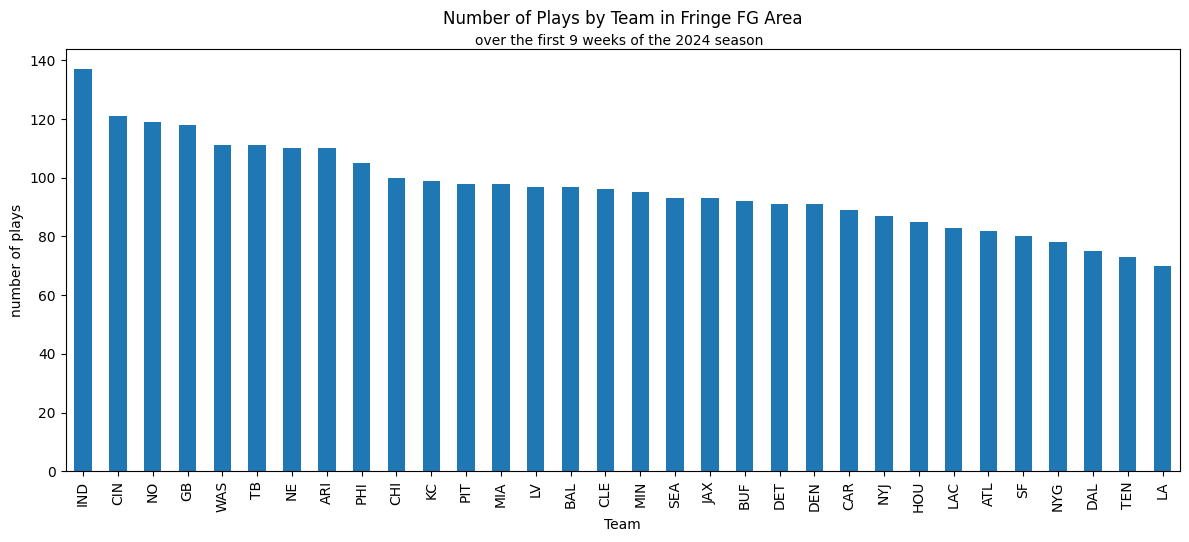

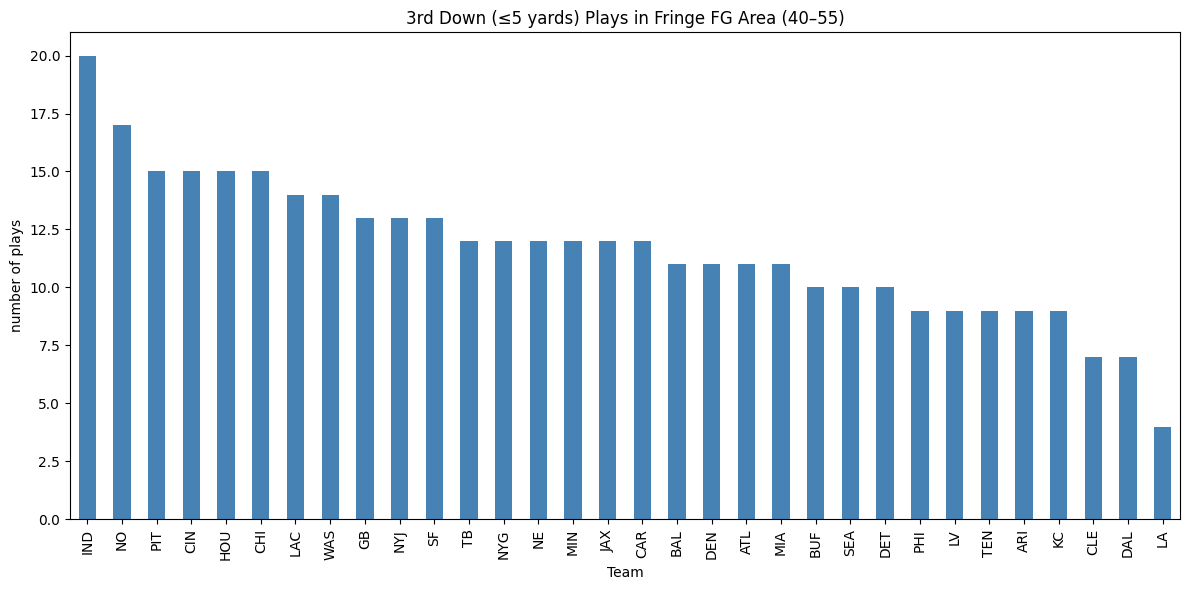




Unique values of passResult: {'R', 'C', nan, 'S', 'IN', 'I'}


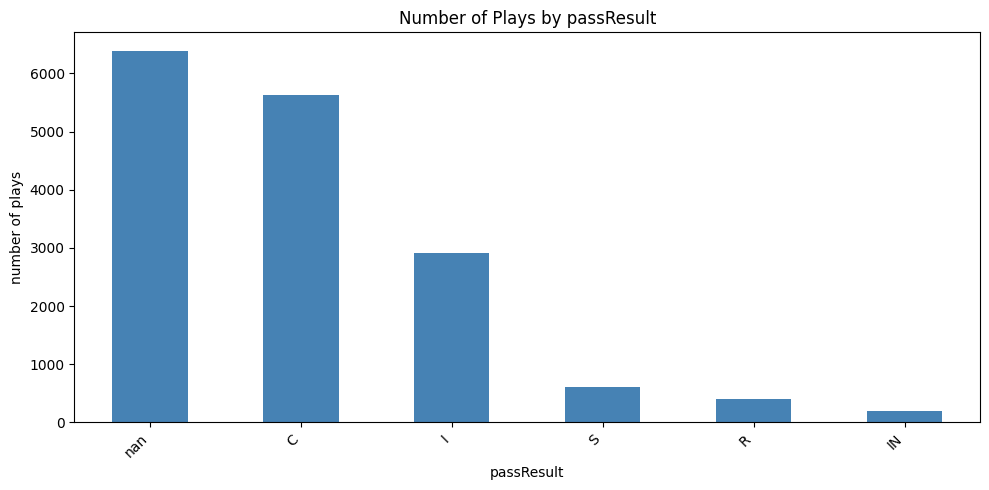

From the above chart we can safely conclude that if there is a value for the passResult field, the play was a pass, otherwise it was a run. Scrambles are counted as R here, not sure if this includes QB draws or just unplanned scrambles.


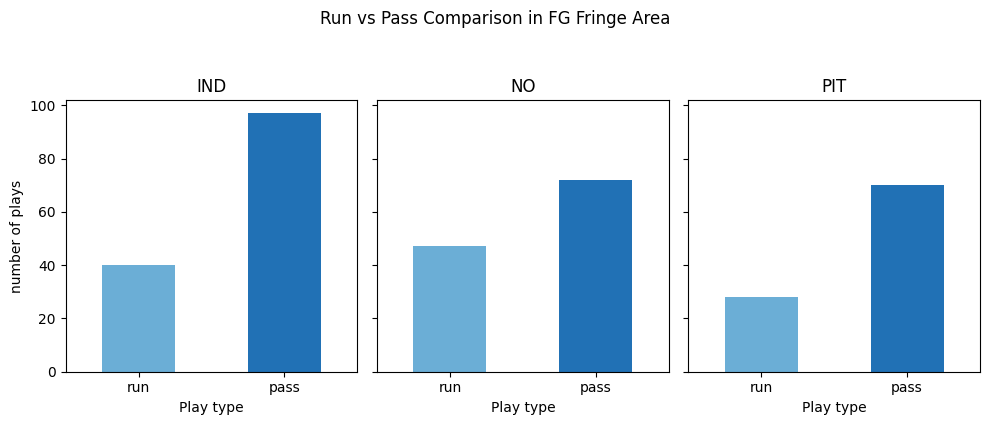

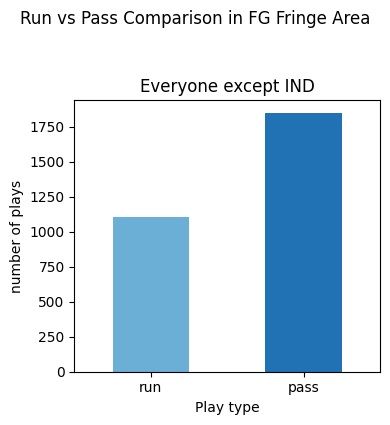

In [38]:
### How many weeks of games in the dataset
print(f'Number of weeks of games in data: {max(games_df['week'])}')

### Number of Home vs Away games for each team
home_counts = games_df.groupby('homeTeamAbbr').size().rename('home_games')
away_counts = games_df.groupby('visitorTeamAbbr').size().rename('visitor_games')

team_counts = (
    pd.concat([home_counts, away_counts], axis=1)
      .fillna(0)
      .astype(int)
      .reset_index()
      .rename(columns={'index': 'team'})
      .sort_values('team')
)

display(team_counts)

### Bar Plot of count of plays within the yard range of interest
fringe_df = plays_df[plays_df["absoluteYardlineNumber"].between(40, 55)]
fringe_df = fringe_df[fringe_df["down"]!=4]
counts = fringe_df["possessionTeam"].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
counts.plot(kind="bar", ax=ax)

ax.set_xlabel("Team")
ax.set_ylabel("number of plays")
ax.set_title("Number of Plays by Team in Fringe FG Area", pad=18)

# subtitle (smaller font)
fig.text(0.52, 0.855, "over the first 9 weeks of the 2024 season",
         ha="center", va="top", fontsize=10)

plt.xticks(rotation=90)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

### Bar Plot of the number of 3rd and 5 or less plays within FG Fringe area
# teams = ["IND", "CIN", "NO"]

mask = (
    plays_df["absoluteYardlineNumber"].between(40, 55) &
    # plays_df["possessionTeam"].isin(teams) &
    (plays_df["down"] == 3) &
    (plays_df["yardsToGo"] <= 5)
)

counts = (
    plays_df.loc[mask, "possessionTeam"]
    .value_counts()
    # .reindex(teams, fill_value=0)
    .astype(int)
)

plt.figure(figsize=(12, 6))
ax = counts.plot(kind="bar", color="steelblue")
ax.set_xlabel("Team")
ax.set_ylabel("number of plays")
ax.set_title("3rd Down (≤5 yards) Plays in Fringe FG Area (40–55)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### passResult EDA
print('\n\n')
print(f'Unique values of passResult: {set(plays_df['passResult'])}')
counts = plays_df["passResult"].value_counts(dropna=False)

plt.figure(figsize=(10, 5))
ax = counts.plot(kind="bar", color="steelblue")
ax.set_xlabel("passResult")
ax.set_ylabel("number of plays")
ax.set_title("Number of Plays by passResult")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print('From the above chart we can safely conclude that if there is a value for the passResult field, the play was a pass, otherwise it was a run. Scrambles are counted as R here, not sure if this includes QB draws or just unplanned scrambles.')

def run_pass_counts(df):
    play_type = df["passResult"].isna().map({True: "run", False: "pass"})
    return play_type.value_counts().reindex(["run", "pass"], fill_value=0).astype(int)

# data subsets
ind_df = fringe_df[fringe_df["possessionTeam"] == "IND"]
no_df  = fringe_df[fringe_df["possessionTeam"] == "NO"]
pit_df = fringe_df[fringe_df["possessionTeam"] == "PIT"]
rest_df = fringe_df[fringe_df["possessionTeam"] != "IND"]

# --- first 3 on the same y-scale (shared y) ---
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)

for ax, (name, gdf) in zip(axes, [("IND", ind_df), ("NO", no_df), ("PIT", pit_df)]):
    counts = run_pass_counts(gdf)
    counts.plot(kind="bar", ax=ax, color=["#6baed6", "#2171b5"])
    ax.set_title(name)
    ax.set_xlabel("Play type")
    ax.set_ylabel("number of plays")
    ax.set_xticklabels(["run", "pass"], rotation=0)

fig.suptitle("Run vs Pass Comparison in FG Fringe Area", y=1.05)
plt.tight_layout()
plt.show()

# --- 4th plot on its own scale ---
fig, ax = plt.subplots(figsize=(4, 4))
counts_rest = run_pass_counts(rest_df)
counts_rest.plot(kind="bar", ax=ax, color=["#6baed6", "#2171b5"])
ax.set_title("Everyone except IND")
ax.set_xlabel("Play type")
ax.set_ylabel("number of plays")
ax.set_xticklabels(["run", "pass"], rotation=0)

fig.suptitle("Run vs Pass Comparison in FG Fringe Area", y=1.05)
plt.tight_layout()
plt.show()

There appear to be enough plays in the area of interest to do this analysis. Later on I plan on doing some feature selection work to pick from the many many features available. I will then look at the frequent itemsets, sparsity of item co-occurrence, etc.

# Research Question Definition

The following questions are specifically for fringe field goal range situations (when 55 - 40 yards from the opposing team's endzone). As tendencies vary widely from team to team, this analysis will be done on a single team.
1. Given pre-snap information such as formation, player coordinates, player shifts, game clock, score differential, yardline, etc., what is indicative of a team passing or running the ball close to field goal range?
    - Specifically analyzing the Indianapolis Colts. Could compare patterns there to the rest of the league as a whole on average.
    - Course Techniques: Large-scale ML, Association Rules, Embedding, Clustering
    - Beyond-course technique(s): None readily apparent as of now
2. Given the above features (and more), now exclusively focusing on known run plays, what is indicative of a specific team running to the right or to the left?
    - Course Techniques: Large-scale ML, Association Rules, Embedding, Clustering
    - Beyond-course technique(s): None readily apparent as of now
3. Given the features mentioned in question 1 (and more) how does a specific team's run/pass tendencies in this situation change week to week?
    - Course Techniques: Large-scale ML, Association Rules, Embedding, Clustering
    - Beyond-course technique(s): Temporal data mining

# Motivation and Feasibility

**Motivation**:
- The NFL is a very large franchise, with an estimated revenue in 2025 of \$21.2 billion and each franchise being worth between \$12.5 and \$5 billion. The success of each team in large part depends on their ability to predict the other team's actions before they happen. One crucial area of play is in the space leading up to field goal range, where a team has to decide to either risk it for more yards, or play it safe and take a field goal. I am to analyze a teams behavior in this decision making over several weeks.

**Non-triviality**:
- There are many factors (an uncountable number of factors) that take part in play-selection decision making.

**Feasibility**:
- Large-scale ML, Association Rule Mining, Clustering, and a rich amount of data all play into the feasibility of providing some insight into this question. I will not be able to solve it completely, but the goal is to better understand general tendencies.

**Risks**:
- The main risk is that the relationship between all possible explanatory variables and the target variable (pass or run, run direction, temporal trend of decision-making) is too complex to meaningfully find tendencies for a given team.
- Another risk could be that there isn't enough data for to effectively analyze this niche of an area. This is easily mitigated by analyzing several teams together that have similar tendencies (prefer pass, prefer run, balanced)

# Methodological Planning

**Course Algorithms**
- Apriori
- FP-Growth
- RandomForestClassifier
- XGBoostClassifier
- K-means
- DBScan

**External Algorithms**
- PrefixSpan
- LSTM
- SHAP

**Evaluation**
- Pattern quality and diversity
- Precision
- F1 Score

**Baselines**
- Single shallow decision tree
- Majority class (pass or run) for team in that scenario

**Notes on Algorithm Decisions**
- Apriori/FP-Growth: Very standard frequent itemset algorithms. I haven't done an analysis with these before and would like to see how they do. They also provide a lot of interpretability which would be key to be able to give a team's defense actionable insights from this analysis.
- RandomForestClassifier/XGBoostClassifier: Expressive models without complete loss of interpretability through feature importances and permutation importances.
- K-means/DBScan: Simple clustering algorithms that each are able to capture data in different but important ways. Could be helpful with the tracking data if I end up being able to access it.
- PrefixSpan: Allows for temporal understanding of frequent itemsets. If there is enough time to analyze how teams' behaviors in this area change overtime this will be helpful.
- LSTM: Good model for time-series data. Loss of interpretability but may be helpful for temporal analysis. Other timeseries approaches could be tried such as ARIMA models or the like but would start with this.
- SHAP: Brings interpretability back a little bit into black box models like LSTM.
- Baseline > Single shallow decision tree: I've used this in the past as a baseline for classification problems. Is easy to do and very interpretable.
- Baseline > Majority class: The simplest baseline possible. If an approach can't figure the relationship out better than this it isn't really learning anything at all (or maybe even learning noise rather than signal)

# Collaboration Declaration
On my honor, I declare the following resources:
1. Collaborators:
- None

2. Web Sources:
- https://www.kaggle.com/competitions/nfl-big-data-bowl-2025/data for the data and definitions

3. AI Tools:
- ChatGPT: I had it make all the charts for me
- ChatGPT: Used to understand PrefixSpan a little better.

4. Papers:
- None